In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# --- 1. 基礎設定 ---
# 定義 Q1~Q4 對應的固定顏色
qubit_colors = {
    "Q1": '#9bbf8a',
    "Q2": '#92afda',
    "Q3": '#f79059',
    "Q4": '#c82423'
}

temperatures = [10, 20, 25,30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 125, 130, 140,145, 150,155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 210] # mK
temperatures = np.arange(10, 230, 5)
qubits_to_plot = ["Q1",  "Q3", "Q4"]
qubit_frequency = [3620.63506, 4029.170438, 3127.600198, 3311.82327] # MHz
all_data = []


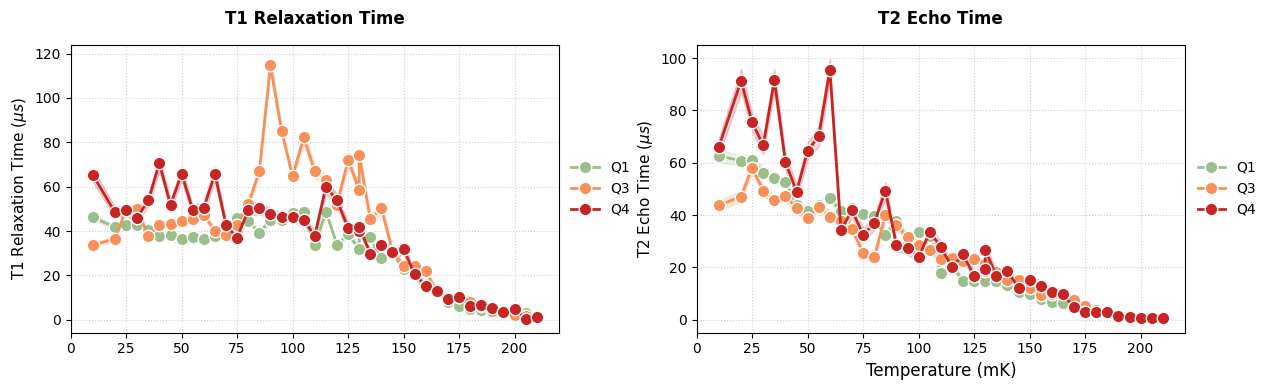

In [34]:

# --- 2. 讀取數據 ---
for temp in temperatures:
    file_path = f"qubit_results_{temp}mK.csv"
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        if not df.empty:
            all_data.append(df)
            # print(f"成功讀取: {file_path}")
    else:
        pass
        # print(f"找不到檔案: {file_path}")

if len(all_data) == 0:
    print("❌ 錯誤：沒有讀取到任何數據！")
else:
    df_total = pd.concat(all_data, ignore_index=True)

    # --- 3. 開始繪圖 ---
    # 定義子圖指標 (欄位名, 誤差欄位名, 顯示標題)
    metrics = [
        ('t1_time', 't1_err', 'T1 Relaxation Time'),
        # ('t2r_time', 't2r_err', 'T2* Ramsey Time'),
        ('t2e_time', 't2e_err', 'T2 Echo Time')
    ]

    fig, axes = plt.subplots(1, len(metrics), figsize=(14, 4), sharex=True)

    for i, (val_col, err_col, title) in enumerate(metrics):
        ax = axes[i]
        
        for q in qubits_to_plot:
            # 挑選資料
            q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
            if q_df.empty:
                continue

            # 取得該 Qubit 專屬顏色
            q_color = qubit_colors.get(q, '#000000') # 預設黑色
            
            # 轉換數據格式
            temp_x = q_df['temp_mK'].values
            y_vals = pd.to_numeric(q_df[val_col], errors='coerce').values
            y_errs = pd.to_numeric(q_df[err_col], errors='coerce').fillna(0).values
            
            # 畫出 Qubit 的中心線與點
            ax.plot(temp_x, y_vals, 'o-', label=f'{q}', color=q_color, 
                    markersize=9, linewidth=2, markeredgecolor='white', markeredgewidth=1)
            
            # 畫出 Qubit 的 Error Band (誤差帶)
            ax.fill_between(temp_x, y_vals - y_errs, y_vals + y_errs, 
                            color=q_color, alpha=0.2)

        # 子圖美化
        ax.set_ylabel(f"{title} ($\mu s$)", fontsize=11)
        ax.set_title(title, fontweight='bold', pad=15)
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False) # 標籤放在右側

    axes[-1].set_xlabel("Temperature (mK)", fontsize=12)
    
    # 調整間距以容納右側 Legend
    plt.tight_layout()
    plt.subplots_adjust(right=0.85) 
    plt.show()

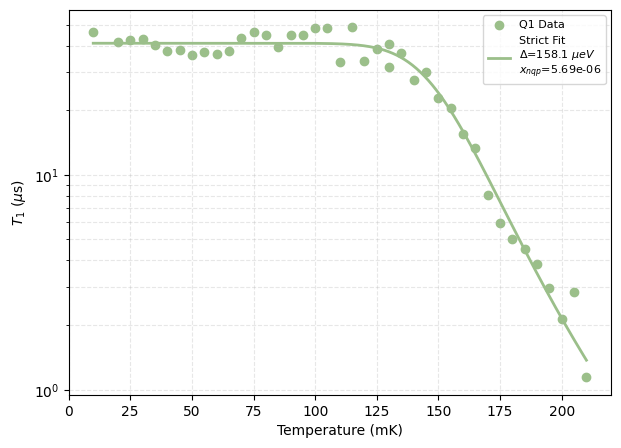

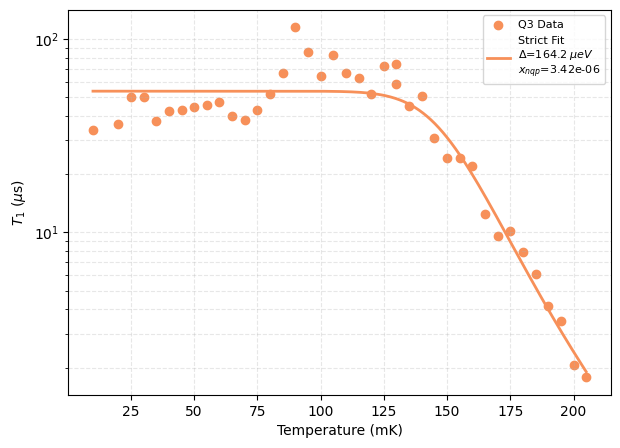

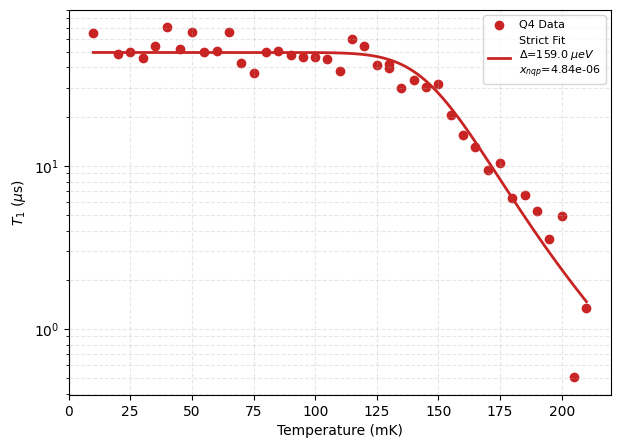


Final Model Results evaluated at T=50 mK
Qubit       x_nqp  Fit fp(GHz)  Fit Delta(ueV)   T1_lim(μs)   T2_lim(μs)
----------------------------------------------------------------------------------------------------
Q1       5.69e-06         3.26           158.1         41.0         82.1
Q3       3.42e-06         3.26           164.2         53.7        107.3
Q4       4.84e-06         3.00           159.0         49.4         98.8

Projection: If xnqp=2e-07 and T=50 mK
Qubit   Fit fp(GHz)  Fit Delta(ueV)     T1_proj(μs)     T2_proj(μs)
----------------------------------------------------------------------------------------------------
Q1             3.26           158.1          1167.3          2334.7
Q3             3.26           164.2           916.9          1833.9
Q4             3.00           159.0          1196.8          2393.6


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import k0

# ══════════════════════════════════════════════════════════════
# 1. 物理常數與硬體參數
# ══════════════════════════════════════════════════════════════

qubit_colors = {"Q1": '#9bbf8a', "Q2": '#92afda', "Q3": '#f79059', "Q4": '#c82423'}
qubit_freqs  = {"Q1": 3620.6, "Q2": 4029.1, "Q3": 3127.6, "Q4": 3311.8} # f_ge (MHz)
EC_MHz       = {"Q1": 210.0,  "Q2": 210.0,  "Q3": 220.0,  "Q4": 215.0} # MHz

# 物理常數
hbar = 1.05457e-34
h    = 6.62607e-34
kB   = 1.38065e-23
e    = 1.60218e-19 # 用於 eV 轉 Joule

def mK_to_K(T_mK): return T_mK * 1e-3
def MHz_to_Hz(f_MHz): return f_MHz * 1e6

# ══════════════════════════════════════════════════════════════
# 2. 嚴格物理模型 (使用 Delta_ueV)
# ══════════════════════════════════════════════════════════════

def gamma1_qp_core(T_K, omega_ge, omega_p, Delta_J, x_nqp):
    """ 論文 Eq. 9 核心邏輯 """
    T_K = np.maximum(T_K, 1e-9)
    hbar_omega_ge = hbar * omega_ge
    arg = hbar_omega_ge / (2 * kB * T_K)
    
    # 第一項：非熱平衡準粒子
    term1 = x_nqp * np.sqrt(2 * Delta_J / hbar_omega_ge)
    # 第二項：熱平衡準粒子
    k0_val = k0(np.minimum(arg, 500.0))
    exp_factor = np.exp(-Delta_J / (kB * T_K))
    term2 = 4 * exp_factor * np.cosh(arg) * k0_val
    
    rate = (1.0 / np.pi) * (omega_p**2 / omega_ge) * (term1 + term2)
    return rate

def total_rate_physics(T_mK, x_nqp, wp_GHz, Delta_ueV, q_label):
    """ 
    總速率 [1/μs]：使用微電子伏特作為能隙單位
    """
    T_K = mK_to_K(T_mK)
    f_ge = MHz_to_Hz(qubit_freqs[q_label])
    omega_ge = 2 * np.pi * f_ge
    omega_p  = 2 * np.pi * wp_GHz * 1e9
    
    # 單位轉換：ueV -> Joule
    Delta_J  = Delta_ueV * 1e-6 * e
    
    rate_rad = gamma1_qp_core(T_K, omega_ge, omega_p, Delta_J, x_nqp)
    return rate_rad / (2 * np.pi) * 1e-6

# ══════════════════════════════════════════════════════════════
# 3. 參數擬合：優化 x_nqp, fp 與 Delta_ueV
# ══════════════════════════════════════════════════════════════

fit_results = {}

for q in ["Q1", "Q2", "Q3", "Q4"]:
    q_df = df_total[df_total['qubit'] == q].sort_values('temp_mK')
    if q_df.empty: continue

    T_data = q_df['temp_mK'].values
    rate_data = 1.0 / q_df['t1_time'].values

    fp_theory = (qubit_freqs[q] + EC_MHz[q]) / 1000.0 # GHz
    
    def fit_func(T_mK, x, wp, du): return total_rate_physics(T_mK, x, wp, du, q)

    try:
        log_rate = np.log10(rate_data)
        def log_fit_func(T_mK, x, wp, du):
            return np.log10(fit_func(T_mK, x, wp, du))

        # 初始值與物理邊界
        # p0[2] 是 Delta_ueV，180 ueV 是鋁的典型值
        p0 = [1e-7, fp_theory, 180.0]
        lb = [1e-12, fp_theory * 0.85, 140.0]
        ub = [1e-3,  fp_theory * 1.15, 250.0]

        popt, _ = curve_fit(log_fit_func, T_data, log_rate, p0=p0, bounds=(lb, ub), maxfev=100000)
        fit_results[q] = popt 

        # 繪圖
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(T_data, 1.0/rate_data, color=qubit_colors[q], label=f'{q} Data')
        
        T_fit = np.linspace(T_data.min(), T_data.max(), 500)
        t1_fit = 1.0 / fit_func(T_fit, *popt)
        ax.plot(T_fit, t1_fit, color=qubit_colors[q], lw=2, 
                label=f'Strict Fit\n$\Delta$={popt[2]:.1f} $\mu eV$\n$x_{{nqp}}$={popt[0]:.2e}')

        ax.set_yscale('log')
        ax.set_xlabel("Temperature (mK)"); ax.set_ylabel(r"$T_1$ ($\mu$s)")
        ax.grid(True, which="both", ls="--", alpha=0.3); ax.legend(fontsize=8)
        plt.show()
    except Exception as e:
        print(f"[{q}] Fitting failed: {e}")

# ══════════════════════════════════════════════════════════════
# 4. 報表與理想預測 (使用 Delta_ueV)
# ══════════════════════════════════════════════════════════════

print("\n" + "=" * 100)
print(f"Final Model Results evaluated at T=50 mK")
print(f"{'Qubit':<6} {'x_nqp':>10} {'Fit fp(GHz)':>12} {'Fit Delta(ueV)':>15} {'T1_lim(μs)':>12} {'T2_lim(μs)':>12}")
print("-" * 100)

for q in ["Q1", "Q2", "Q3", "Q4"]:
    if q not in fit_results: continue
    x_f, wp_f, du_f = fit_results[q]
    
    t1_lim = 1.0 / total_rate_physics(50.0, x_f, wp_f, du_f, q)
    
    # 去相位計算同步改為 Joule 基準
    T_K = 50e-3
    Delta_J = du_f * 1e-6 * e
    Ec_J = MHz_to_Hz(EC_MHz[q]) * h
    g_phi = (Ec_J / (np.pi * hbar)) * (kB * T_K / Delta_J) * np.exp(-Delta_J / (kB * T_K))
    g_phi_us = g_phi / (2 * np.pi) * 1e-6
    t2_lim = 1.0 / (1.0/(2*t1_lim) + g_phi_us)
    
    print(f"{q:<6} {x_f:>10.2e} {wp_f:>12.2f} {du_f:>15.1f} {t1_lim:>12.1f} {t2_lim:>12.1f}")

print("\n" + "=" * 100)
TARGET_XNQP = 20e-8
TARGET_T_MK = 50.0
print(f"Projection: If xnqp={TARGET_XNQP:.0e} and T={TARGET_T_MK:.0f} mK")
print(f"{'Qubit':<6} {'Fit fp(GHz)':>12} {'Fit Delta(ueV)':>15} {'T1_proj(μs)':>15} {'T2_proj(μs)':>15}")
print("-" * 100)

for q in ["Q1", "Q2", "Q3", "Q4"]:
    if q not in fit_results: continue
    _, wp_f, du_f = fit_results[q]

    t1_p = 1.0 / total_rate_physics(TARGET_T_MK, TARGET_XNQP, wp_f, du_f, q)
    
    T_K_p = TARGET_T_MK * 1e-3
    Delta_J_p = du_f * 1e-6 * e
    g_phi_p = (MHz_to_Hz(EC_MHz[q])*h / (np.pi*hbar)) * (kB*T_K_p/Delta_J_p) * np.exp(-Delta_J_p/(kB*T_K_p))
    t2_p = 1.0 / (1.0/(2*t1_p) + (g_phi_p / (2*np.pi) * 1e-6))

    print(f"{q:<6} {wp_f:>12.2f} {du_f:>15.1f} {t1_p:>15.1f} {t2_p:>15.1f}")
print("=" * 100)


